# Misspecified Bayesian DRO experiment

The following experiment compares three different posteriors over two data-generating processes (DGPs) on the newsvendor problem.
The objective function is $G(x, \xi) = h \max (0, x - \xi) + b \max (0, \xi - x) + c x$ where $h = 3$, $b = 8$, $c = 0$.
The decision variable $5 \leq x \leq 50$ is continuous.
The customer demand $\xi$ has support $\Xi = \mathbb{R}^+$.


In each replication $j = 1,\ldots,K$, we are given $N+M$ data points $\xi_1^{(j)}, \ldots, \xi_N^{(j)}, \xi_{N+1}^{(j)}, \ldots, \xi_{N+M}^{(j)}$ where the first $N=20$ points are the training samples and the last $M=50$ points are the test sample.
For each $\epsilon$ and each replication $j$, we calculate the out-of-sample mean $\mu^{(j)}(\epsilon)$ and variance $v^{(j)}(\epsilon)$ of the objective function under the $M$ test points:
$$
    \mu^{(j)}(\epsilon) := \mathbb{E}_{\xi \sim \mathbb{P}^\star}~{[G(x^{(j)}(\epsilon), \xi)]} = \frac{1}{M}~\sum_{i=1}^{M}~{G(x^{(j)}(\epsilon), \xi_{i}^{(j)})} \\
    v^{(j)}(\epsilon) := \mathbb{V}_{\xi \sim \mathbb{P}^\star}~{[G(x^{(j)}(\epsilon), \xi)]} = \frac{1}{M-1}~\sum_{i=1}^{M}~{\left(G(x^{(j)}(\epsilon), \xi_{i}^{(j)}) - \mu^{(j)}(\epsilon)\right)^2}
$$
where $\mathbb{P}^\star$ is the true data-generating process (DGP), $K$ is the number of replications, and $x^{(j)}(\epsilon)$ is the solution given by the Bayesian DRO algorithm on replication $j = 1,\ldots,K$.
Over all replications, we then calculate $\hat{\mu}_M(\epsilon)$ and $\hat{v}_M(\epsilon)$, where
$\hat{\mu}_M(\epsilon)$ is the mean-of-the-means,
and $\hat{v}_M(\epsilon)$ is the mean-of-the-variances plus the variance-of-the-means.
$$
    \hat{\mu}_M(\epsilon) :=  \frac{1}{K}~\sum_{j=1}^{K}~{ \mu^{(j)}(\epsilon)}, \\
    \hat{v}_M(\epsilon) := \underbrace{\frac{1}{K}~\sum_{j=1}^{K}~{v^{(j)}(\epsilon)}}_{\text{mean-of-the-variances}} + \underbrace{\frac{1}{K-1}~\sum_{j=1}^{K}~{\left( \mu^{(j)}(\epsilon) - \hat{\mu}_M(\epsilon) \right)^2}}_{\text{variance-of-the-means}}.
$$
Note that setting $M=1$ recovers the out-of-sample mean and variance in the usual way.


## Implementation details

In the following notebook, we concatenate all the CSV files together, then group by $\epsilon$ and the posterior method (`bayes`, `wll`, `mmd`):
- For each epsilon, posterior, & DGP, we save a CSV file where each row corresponds to a single replication $k$. The CSV contains the solution, time taken in seconds, out-of-sample mean $\mu^{(j)}(\epsilon)$, and out-of-sample variance $v^{(j)}(\epsilon)$.
- Each CSV file has a unique ID which maps to the `experiment.json` file. All the parameters can be found in the `experiment.csv` file.





In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation
from mis_dro.dataset import data_generation_outliers


In [2]:
experiment_dir = Path("/dcs/large/u1508153/misdro/newsvendor_1d")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col="uuid")

# check the number of train/test observations is the same:
assert len(results_df["num_observations"].unique()) == 1
assert len(results_df["num_test_observations"].unique()) == 1
num_observations = results_df["num_observations"]
num_test_observations = results_df["num_test_observations"]
results_df

,replication,mean_cost,var_cost,solution,dgp_time,likelihood_time,posterior_time,solve_time,algorithm,contamination,dgp,epsilon,lengthscale,num_likelihood_samples,num_observations,num_posterior_samples,num_replications,num_test_observations,posterior
uuid,,,,,,,,,,,,,,,,,,,
680e0476-f2db-4d96-a213-3942c5596a89,0,71.338200,1877.593985,34.45,0.000609,0.012852,0.000200,563.059103,bayesian_dro,0.0,exponential,0.001,-1.0,100,20,100,200,50,bayes
680e0476-f2db-4d96-a213-3942c5596a89,1,102.263323,32474.466263,28.13,0.000522,0.011716,0.000330,529.081552,bayesian_dro,0.0,exponential,0.001,-1.0,100,20,100,200,50,bayes
680e0476-f2db-4d96-a213-3942c5596a89,2,59.619183,4474.581151,23.73,0.000382,0.011602,0.000172,511.974161,bayesian_dro,0.0,exponential,0.001,-1.0,100,20,100,200,50,bayes
680e0476-f2db-4d96-a213-3942c5596a89,3,94.777515,14854.525125,22.22,0.000394,0.011701,0.000177,585.058361,bayesian_dro,0.0,exponential,0.001,-1.0,100,20,100,200,50,bayes
680e0476-f2db-4d96-a213-3942c5596a89,4,99.306645,13496.165716,35.70,0.000437,0.013956,0.000215,575.859742,bayesian_dro,0.0,exponential,0.001,-1.0,100,20,100,200,50,bayes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46811520-40da-4242-bda6-d7392f018266,195,119.612638,1023.503374,50.00,0.000643,0.009017,37.725969,79.259925,bayesian_dro,0.2,contaminated_exp,3.000,-1.0,100,20,100,200,50,mmd
46811520-40da-4242-bda6-d7392f018266,196,127.189470,608.042652,50.00,0.000634,0.008642,37.638553,77.054469,bayesian_dro,0.2,contaminated_exp,3.000,-1.0,100,20,100,200,50,mmd
46811520-40da-4242-bda6-d7392f018266,197,115.586466,972.036920,50.00,0.000636,0.008969,37.694951,77.224410,bayesian_dro,0.2,contaminated_exp,3.000,-1.0,100,20,100,200,50,mmd


In [3]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "posterior"])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
})
df

mean_cost              \
                                                       mean         var   
algorithm    dgp              epsilon posterior                           
bayesian_dro contaminated_exp 0.001   bayes       63.542741  330.937458   
                                      mmd         46.179590   97.075924   
                                      wll         62.120195  306.461865   
                              0.002   bayes       64.318063  336.763605   
                                      mmd         46.449693   96.860238   
...                                                     ...         ...   
             truncated_normal 2.500   mmd        110.509128   25.770707   
                                      wll        103.296757  125.989845   
                              3.000   bayes      106.337972   92.916836   
                                      mmd        110.867028   18.703679   
                                      wll        105.800483   93.592659   

                                                    var_cost posterior_time  \
                                                        mean           mean   
algorithm    dgp              epsilon posterior                               
bayesian_dro contaminated_exp 0.001   bayes       969.473005       0.000142   
                                      mmd        1418.512036      57.302277   
                                      wll         988.711369       0.012479   
                              0.002   bayes       959.199675       0.000152   
                                      mmd        1390.737940      58.447617   
...                                                      ...            ...   
             truncated_normal 2.500   mmd         554.509852      53.969823   
                                      wll         551.601442       0.011635   
                              3.000   bayes       552.128826       0.000160   
                                      mmd         554.509852      50.937310   
                                      wll         552.618262       0.012959   

                                                 solve_time  
                                                       mean  
algorithm    dgp              epsilon posterior              
bayesian_dro contaminated_exp 0.001   bayes      400.385348  
                                      mmd        377.579321  
                                      wll        400.594969  
                              0.002   bayes      394.627460  
                                      mmd        346.244994  
...                                                     ...  
             truncated_normal 2.500   mmd        129.720777  
                                      wll        128.222313  
                              3.000   bayes      124.018832  
                                      mmd        109.656118  
                                      wll        117.466271  

[162 rows x 5 columns]

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

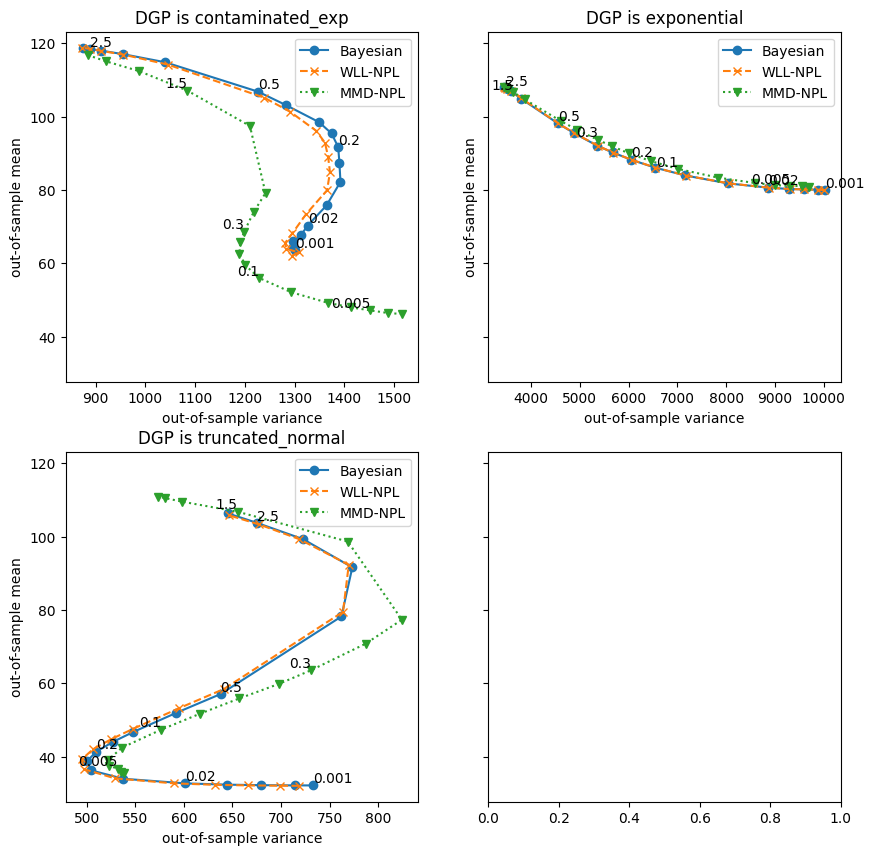

In [4]:
def plot_dgp(dgp: str, axis, algorithm: str = "bayesian_dro"):
    # get a dataframe for each posterior
    bayes_df = df.loc[algorithm, dgp, :, "bayes"]
    wll_df = df.loc[algorithm, dgp, :, "wll"]
    mmd_df = df.loc[algorithm, dgp, :, "mmd"]

    # mean of variances + variance of means
    bayes_bootstrap_var = bayes_df["var_cost"]["mean"] + bayes_df["mean_cost"]["var"]
    wll_bootstrap_var = wll_df["var_cost"]["mean"] + wll_df["mean_cost"]["var"]
    mmd_bootstrap_var = mmd_df["var_cost"]["mean"] + mmd_df["mean_cost"]["var"]

    # plot mean-variance trade-off
    axis.plot(bayes_bootstrap_var, bayes_df["mean_cost"]["mean"], marker='o', linestyle="solid", label="Bayesian")
    axis.plot(wll_bootstrap_var, wll_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
    axis.plot(mmd_bootstrap_var, mmd_df["mean_cost"]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
        if i % 4 == 0:
            axis.text(bayes_bootstrap_var[epsilon], bayes_df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        if (i+2) % 4 == 0:
            axis.text(mmd_bootstrap_var[epsilon], mmd_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

# plot mean-variance trade-off for each DGP
dgp_list = list(df.index.get_level_values("dgp").unique())
nrows = int(np.ceil(len(dgp_list)/2.0))
fig, axes = plt.subplots(nrows=nrows, ncols=2, sharex=False, sharey=True, figsize=(10,10))
for i, dgp in enumerate(dgp_list):
    row = int(np.floor(i / 2.0))
    col = i % 2
    plot_dgp(dgp, axes[row][col])

## Solve time

Interestingly, the solve time (in seconds) for the Bayesian DRO algorithm doubles as $\epsilon \to 0$. 
The top row shows the solve time for two DGPs.
The bottom row shows the posterior sampling time for MMD, Bayes, and WLL.

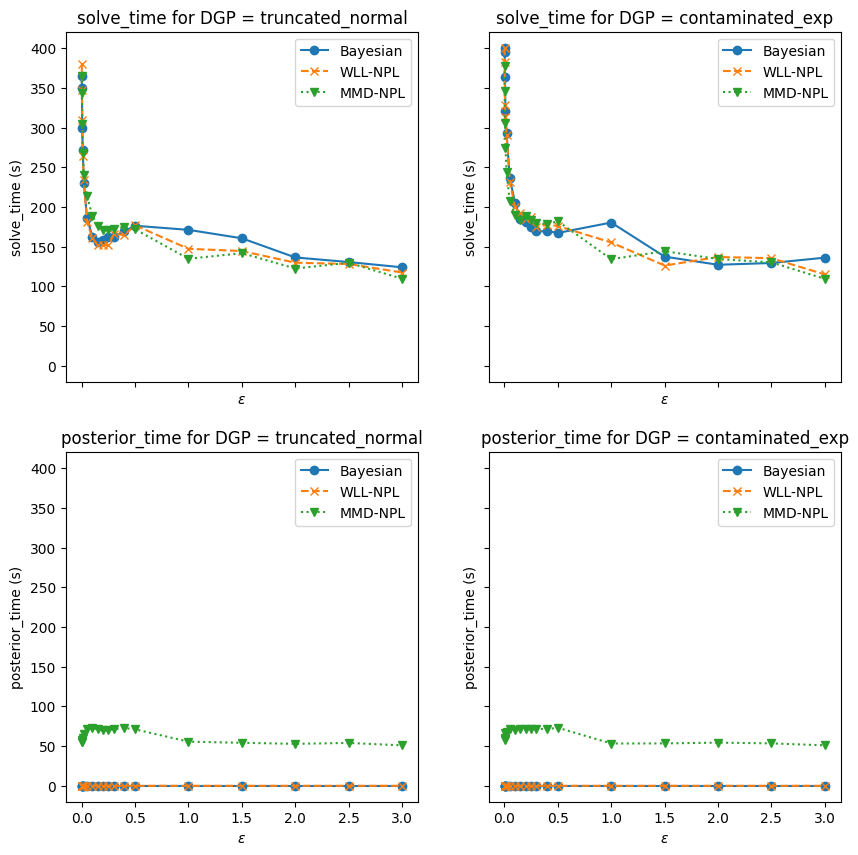

In [5]:
def plot_time_taken(dgp, time_name, axis, algorithm: str = "bayesian_dro"):
    # get a dataframe for each posterior
    bayes_df = df.loc[algorithm, dgp, :, "bayes"]
    wll_df = df.loc[algorithm, dgp, :, "wll"]
    mmd_df = df.loc[algorithm, dgp, :, "mmd"]
    
    axis.plot(bayes_df.index, bayes_df[time_name]["mean"], marker='o', linestyle="solid", label="Bayesian")
    axis.plot(wll_df.index, wll_df[time_name]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
    axis.plot(mmd_df.index, mmd_df[time_name]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")
    axis.set_title(f"{time_name} for DGP = {dgp}")
    axis.legend()
    axis.set_xlabel("$\epsilon$")
    axis.set_ylabel(f"{time_name} (s)")


fig, (row1, row2) = plt.subplots(ncols=2, nrows=2, sharex=True, sharey=True, figsize=(10,10))
plot_time_taken("truncated_normal", "solve_time", row1[0])
plot_time_taken("contaminated_exp", "solve_time", row1[1])
plot_time_taken("truncated_normal", "posterior_time", row2[0])
plot_time_taken("contaminated_exp", "posterior_time", row2[1])

## Data-generating processes

We plot the density histograms from each of the DGPs.
Following from Section 4.1 of Shapiro et al. (2023), the truncated normal has mean 10 and variance 100, and is truncated above zero.
Again following from Section 4.1 of Shapiro et al. (2023), the exponential distribution has rate parameter $\lambda^{-1} = 20$, i.e. the mean is 20.

We introduce a contaminated exponential distribution with contamination level 0.2 where the contimination only affects the $N$ training samples.
That is, when sampling the training samples $\hat{\xi}_1,\ldots,\hat{\xi}_N$, 80% comes from the an exponential distribution $Exp(\lambda_1)$ with $\lambda^{-1}_1 = 10$ where as the other 20% of the data comes from an contaminating exponentional distribution $Exp(\lambda_2)$ with $\lambda^{-1}_2 = 70$.
However, the $M$ testing samples $\hat{\xi}_{N+1},\ldots,\hat{\xi}_{N+M}$ are all drawn from $Exp(\lambda_1)$.

In the below plots, the bottom-left plot shows the training data from the contaminated exponential distribution, where as the bottom-right shows the test data drawn only from $Exp(\lambda_1)$. 

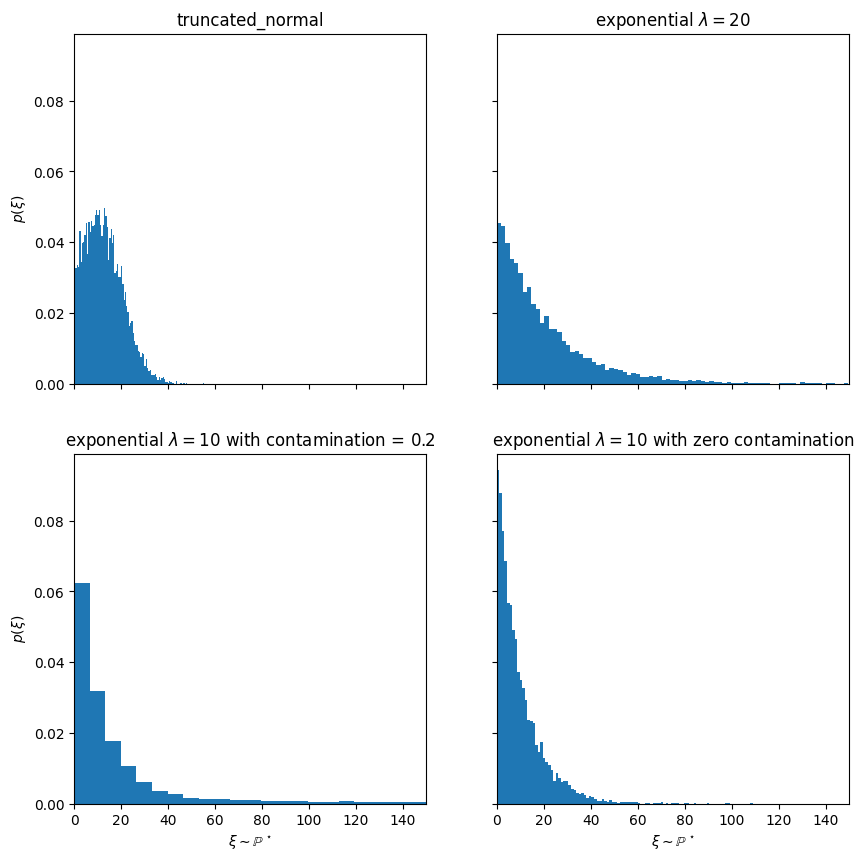

In [6]:
generator = np.random.default_rng(0)
nbins = 100
N = 10000

fig, axes = plt.subplots(ncols=2, nrows=2, sharex=True, sharey=True, figsize=(10,10))

axes[0][0].hist(data_generation(N, random_state=generator), bins=nbins, label="truncated normal", density=True)
axes[0][1].hist(expon.rvs(scale=20.0, size=N, random_state=generator), bins=nbins,  label="exponential", density=True)
axes[1][0].hist(data_generation_outliers(N, contamination=0.2, random_state=generator), bins=nbins, label="contamination", density=True)
axes[1][1].hist(data_generation_outliers(N, contamination=0.0, random_state=generator), bins=nbins, density=True)
axes[0][0].set_title("truncated_normal")
axes[0][1].set_title("exponential $\lambda = 20$")
axes[1][0].set_title("exponential $\lambda = 10$ with contamination = 0.2")
axes[1][1].set_title("exponential $\lambda = 10$ with zero contamination")

axes[0][0].set_xlim(0, 150)

axes[1][0].set_xlabel(r"$\xi \sim \mathbb{P}^\star$")
axes[1][1].set_xlabel(r"$\xi \sim \mathbb{P}^\star$")
axes[0][0].set_ylabel(r"$p(\xi)$")
axes[1][0].set_ylabel(r"$p(\xi)$")

plt.show()